# Modelo continuo — cuota de voto

**La pregunta de la tesis:** no "¿quién gana?" (1 bit por contienda) sino "¿qué **cuota de voto**
saca cada candidato?" — un objetivo real y con gradiente para **cada uno de los 120 candidatos**.
Aquí vive la señal que el binario aplastaba.

**El modelo:** la cuota de voto está acotada en (0,1), así que usamos **regresión logística
fraccional** (Papke–Wooldridge): un GLM con familia binomial y *link* logit. El link respeta los
límites sin transformar a mano y conecta con la escala log-odds donde vimos que la señal es más limpia.

**Métricas (ya no es "acertó al ganador"):**
- **MAE** — error absoluto medio de la cuota predicha, en puntos porcentuales (lo más interpretable).
- **R² fuera de muestra** — qué fracción de la varianza de la cuota explicamos en contiendas nuevas.
- **Top-1** — el argmax de la cuota predicha, solo para tender el puente con el baseline binario (71%).

> Validación: leave-one-contest-out. Comparamos contra dos baselines ingenuos: "cuota de
> interacciones = cuota de voto" (la línea de 45°) y "todos iguales" (1/k).


---
## 0 — Datos, objetivo y features


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut

sns.set_theme(style="whitegrid"); pd.set_option("display.max_columns", None)
%matplotlib inline
AZUL_SABANA, ROJO, GRIS = "#1A2F6F", "#FF4B4B", "#A9A9A9"


In [2]:
# ---- Carga (ahora SÍ traemos población) ----
base_path = os.getcwd()
excel_path = os.path.join(os.path.dirname(base_path), "Colombia", "Resultados electorales.xlsx")
csv_unificado  = os.path.join(base_path, "resultados", "redes_unificadas.csv")
csv_seguidores = os.path.join(base_path, "resultados", "seguidores.csv")

df_redes      = pd.read_csv(csv_unificado, sep=";", encoding="utf-8-sig")
df_electoral  = pd.read_excel(excel_path, sheet_name="Candidatos E-26 ALC").rename(columns={"ID Candidato":"id_candidato"})
df_poblacion  = pd.read_excel(excel_path, sheet_name="Población 2023 (DANE)")
df_seguidores = pd.read_csv(csv_seguidores, sep=";", encoding="utf-8-sig").fillna(0)
for ex in ["68547","68081"]:
    df_redes = df_redes[~df_redes["id_candidato"].str.contains(ex, na=False)]

df_completo = df_redes.merge(df_seguidores[["id_candidato","tiktok_followers","twitter_followers","facebook_followers"]], on="id_candidato", how="left")
df_completo = df_completo.merge(df_electoral[["id_candidato","Candidato","Ganador","Votos"]], on="id_candidato", how="left")
df_completo["DIVIPOLA"] = df_completo["id_candidato"].astype(str).str.split("-").str[1].str.zfill(5)
df_poblacion["DIVIPOLA"] = pd.to_numeric(df_poblacion["DIVIPOLA"], errors="coerce").fillna(0).astype(int).astype(str).str.zfill(5)
df_completo = df_completo.merge(df_poblacion[["DIVIPOLA","Población 2023"]], on="DIVIPOLA", how="left")
TIPOS = ["likes","comentarios","compartidos","favoritos","fb_haha","fb_care","fb_wow","fb_sad","fb_angry"]
cols_pres = [c for c in TIPOS if c in df_completo.columns]
df_completo["interacciones_totales"] = df_completo[cols_pres].sum(axis=1)
print(f"Candidatos: {df_completo['id_candidato'].nunique()} | Municipios: {df_completo['DIVIPOLA'].nunique()}")


Candidatos: 120 | Municipios: 31


In [3]:
# ---- prepare_lens_data + matriz con OBJETIVO (cuota de voto) y FEATURES ----
FOLLOWER_COL = {"Facebook":"facebook_followers","Twitter":"twitter_followers","TikTok":"tiktok_followers"}
def prepare_lens_data(df, metric_col, lente="dominancia", platform=None):
    data = df.copy()
    if platform is not None: data = data[data["red_social"]==platform]
    if len(data)==0 or metric_col not in data.columns: return pd.DataFrame()
    seg = data[FOLLOWER_COL[platform]] if platform else data[list(FOLLOWER_COL.values())].sum(axis=1)
    data = data.assign(_seg=seg)
    agg = data.groupby(["DIVIPOLA","id_candidato","Candidato","Ganador"]).agg(
        metric_sum=(metric_col,"sum"), n_posts=(metric_col,"count"),
        votos=("Votos","first"), pob=("Población 2023","first")).reset_index()
    if lente in ("totales","dominancia"): agg["v"]=agg["metric_sum"]
    elif lente=="por_post":               agg["v"]=agg["metric_sum"]/agg["n_posts"].replace(0,np.nan)
    agg = agg.replace([np.inf,-np.inf], np.nan)
    agg["pct_metric"] = (agg["v"]/agg.groupby("DIVIPOLA")["v"].transform("sum"))*100
    return agg[agg.groupby("DIVIPOLA")["v"].transform("sum")>0]

d = prepare_lens_data(df_completo, "likes", "dominancia", None)   # señal digital principal
d = d.rename(columns={"pct_metric":"likes_dom"})
dc = prepare_lens_data(df_completo, "comentarios", "dominancia", None)[["id_candidato","pct_metric"]].rename(columns={"pct_metric":"coment_dom"})
base = d.merge(dc, on="id_candidato", how="left")

# OBJETIVO: cuota de voto dentro del campo competitivo
base["total_votos"] = base.groupby("DIVIPOLA")["votos"].transform("sum")
base["vote_frac"]   = (base["votos"]/base["total_votos"]).clip(1e-4, 1-1e-4)
# FEATURES
base["n_candidatos"] = base.groupby("DIVIPOLA")["id_candidato"].transform("count")
base["log_pob"]      = np.log(base["pob"].clip(lower=1))
def to_logit(p_pct, eps=1e-3):
    p = np.clip(p_pct/100, eps, 1-eps); return np.log(p/(1-p))
base["logit_likes"]  = to_logit(base["likes_dom"])
base["logit_coment"] = to_logit(base["coment_dom"])
base = base.dropna(subset=["vote_frac","logit_likes","log_pob"]).reset_index(drop=True)
print(f"Filas: {len(base)} | Contiendas: {base['DIVIPOLA'].nunique()}")
base[["DIVIPOLA","Candidato","vote_frac","likes_dom","logit_likes","n_candidatos","log_pob"]].head()


Filas: 120 | Contiendas: 31


,DIVIPOLA,Candidato,vote_frac,likes_dom,logit_likes,n_candidatos,log_pob
0,05001,Federico Andres Gutierrez Zuluaga,0.814960,61.082575,0.450785,6,14.80893
1,05001,Rodolfo Andres Correa Vargas,0.012503,0.028290,-6.906755,6,14.80893
2,05001,Albert Yordano Corredor Bustamante,0.031833,24.042407,-1.150356,6,14.80893
3,05001,Maria Paulina Aguinaga Lezcano,0.014989,0.666633,-5.003997,6,14.80893
4,05001,Juan Carlos Upegui Vanegas,0.111964,13.605918,-1.848414,6,14.80893


---
## 1 — Ajuste e interpretación (sobre todo el dataset)

Regresión logística fraccional. Empezamos con la señal digital (`logit_likes`) y errores estándar
**agrupados por contienda**.


In [4]:
Xn = sm.add_constant(base[["logit_likes"]])
mod = sm.GLM(base["vote_frac"], Xn, family=sm.families.Binomial()).fit(
        cov_type="cluster", cov_kwds={"groups": base["DIVIPOLA"]})
print(mod.summary())
print(f"\nEfecto: +1 en logit(cuota de likes) multiplica los odds de la cuota de voto por "
      f"{np.exp(mod.params['logit_likes']):.2f}")


                 Generalized Linear Model Regression Results                  
Dep. Variable:              vote_frac   No. Observations:                  120
Model:                            GLM   Df Residuals:                      118
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -45.007
Date:                Thu, 18 Jun 2026   Deviance:                       14.093
Time:                        00:02:29   Pearson chi2:                     15.6
No. Iterations:                     5   Pseudo R-squ. (CS):            0.08935
Covariance Type:              cluster                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.4995      0.072     -6.919      

---
## 2 — Validación leave-one-contest-out

Dejamos cada contienda afuera, ajustamos con el resto y predecimos la cuota de sus candidatos.


In [5]:
def logo_predict(base, feats, y_col="vote_frac", group="DIVIPOLA"):
    '''Devuelve predicciones fuera de muestra (una por candidato) con leave-one-contest-out.'''
    logo = LeaveOneGroupOut()
    X = base[feats].values.astype(float); y = base[y_col].values; g = base[group].values
    pred = np.full(len(y), np.nan)
    for tr, te in logo.split(X, y, g):
        sc = StandardScaler().fit(X[tr])
        Xtr = sm.add_constant(sc.transform(X[tr]))
        Xte = sm.add_constant(sc.transform(X[te]), has_constant="add")
        try:
            m = sm.GLM(y[tr], Xtr, family=sm.families.Binomial()).fit()
            pred[te] = m.predict(Xte)
        except Exception:
            pred[te] = y[tr].mean()
    return pred

def metricas(base, pred, group="DIVIPOLA"):
    y = base["vote_frac"].values
    mae = np.mean(np.abs(y - pred)) * 100
    ss_res = np.sum((y - pred)**2); ss_tot = np.sum((y - y.mean())**2)
    r2 = 1 - ss_res/ss_tot
    # top-1: argmax de la cuota predicha = ganador real?
    ac = tot = 0
    tmp = base.assign(pred=pred)
    for gr, s in tmp.groupby(group):
        gana_real = s.loc[s["vote_frac"].idxmax(), "id_candidato"]
        gana_pred = s.loc[s["pred"].idxmax(), "id_candidato"]
        ac += int(gana_real == gana_pred); tot += 1
    return dict(MAE_pp=round(mae,2), R2_oos=round(r2,3), top1=round(100*ac/tot,1))

pred_modelo = logo_predict(base, ["logit_likes"])
print("Modelo (solo logit_likes):", metricas(base, pred_modelo))

# Baselines ingenuos
pred_prop = (base["likes_dom"]/100).values          # cuota interacciones = cuota voto (línea 45°)
pred_unif = (1/base["n_candidatos"]).values          # todos iguales
print("Baseline proporcionalidad :", metricas(base, pred_prop))
print("Baseline uniforme (1/k)   :", metricas(base, pred_unif))


Modelo (solo logit_likes): {'MAE_pp': np.float64(11.52), 'R2_oos': np.float64(0.46), 'top1': 71.0}
Baseline proporcionalidad : {'MAE_pp': np.float64(12.61), 'R2_oos': np.float64(0.185), 'top1': 71.0}
Baseline uniforme (1/k)   : {'MAE_pp': np.float64(12.49), 'R2_oos': np.float64(0.306), 'top1': 38.7}


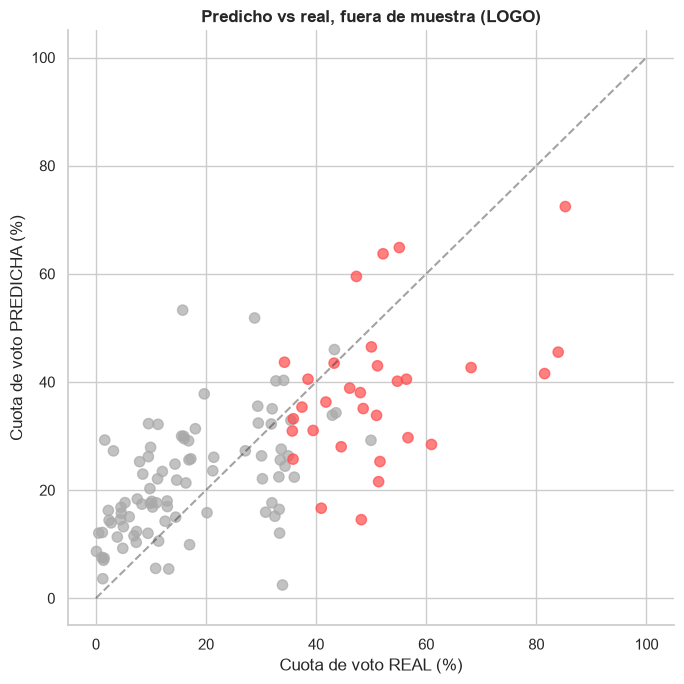

In [6]:
# --- Predicho vs real (fuera de muestra) ---
fig, ax = plt.subplots(figsize=(7,7))
ax.scatter(base["vote_frac"]*100, pred_modelo*100,
           c=np.where(base["Ganador"]=="Sí", ROJO, GRIS), alpha=0.7, s=55)
ax.plot([0,100],[0,100],"k--",alpha=0.4)
ax.set_xlabel("Cuota de voto REAL (%)"); ax.set_ylabel("Cuota de voto PREDICHA (%)")
ax.set_title("Predicho vs real, fuera de muestra (LOGO)", fontweight="bold")
ax.spines[["top","right"]].set_visible(False); plt.tight_layout(); plt.show()


---
## 3 — ¿Aporta el territorio? (dejemos que el dato responda)

Antes hablamos de la sutileza: la población es **constante dentro de la contienda**, así que como
*efecto principal* casi no cambia el **orden** de las cuotas (su valor real es como **moderador**:
cuánto pesan las redes según el tamaño del municipio). Aquí lo comprobamos empíricamente comparando
tres especificaciones bajo la misma validación.


In [7]:
# logit_likes × log_pob como término de interacción (moderador)
base["likes_x_pob"] = base["logit_likes"] * (base["log_pob"] - base["log_pob"].mean())

specs = {
    "Solo digital":            ["logit_likes"],
    "Digital + comentarios":   ["logit_likes", "logit_coment"],
    "Digital + n_cand + pob":  ["logit_likes", "n_candidatos", "log_pob"],
    "Digital × población (moderador)": ["logit_likes", "likes_x_pob"],
}
filas = []
for nombre, fs in specs.items():
    filas.append({"especificación": nombre, "n_features": len(fs), **metricas(base, logo_predict(base, fs))})
pd.DataFrame(filas)


,especificación,n_features,MAE_pp,R2_oos,top1
0,Solo digital,1,11.52,0.460,71.0
1,Digital + comentarios,2,11.75,0.438,71.0
2,Digital + n_cand + pob,3,10.34,0.510,71.0
3,Digital × población (moderador),2,10.33,0.509,71.0


**Cómo leerlo.** Si agregar territorio NO baja el MAE (o lo sube), confirma lo que veníamos
diciendo: con 31 contiendas, más variables = sobreajuste, y el territorio como efecto principal se
diluye. Si la versión *moderador* (interacción) ayuda algo, ahí está el papel real de la población.
No fuerces variables que el MAE fuera de muestra no premie.


---
## Notas y siguiente paso

- **MAE en puntos porcentuales** es tu titular: "predigo la cuota de voto con un error medio de X pp".
  Compáralo siempre contra el baseline de proporcionalidad — si el modelo no le gana, la relación es
  esencialmente 1:1 y el modelo aporta poco más que la intuición.
- **Top-1 ≈ 71%.** El modelo continuo, al hacer argmax, recupera el resultado binario *y además* da
  la cuota. Es decir, el continuo **contiene** al binario, no lo reemplaza a ciegas.
- **Sutileza composicional.** Para que las cuotas predichas sumen 100% dentro de la contienda,
  renormaliza (divide cada predicción por la suma de su contienda). El argmax no cambia.
- **Capa Colombia.** Cuando cargues abstención (Registraduría), categoría DNP y riesgo MOE, entran
  como nuevas columnas o moderadores y mides el Δ MAE — sin romper el núcleo agnóstico.
- **Alternativa:** regresión beta (`statsmodels` `BetaModel`) si quieres modelar también la dispersión.
- **Validación definitiva:** la presidencial 2026, corriendo el núcleo el día antes.
